In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
from typing import Optional

In [3]:
TICKERS = ['AAPL']
BENCHMARK = "SPY"
START = "2021-01-01"
END = None
df = yf.download(TICKERS,start=START,end=END,auto_adjust=True,progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740868,129.821783,123.166001,129.734338,143301900
2021-01-05,127.295456,128.004769,124.788605,125.235569,97664900
2021-01-06,123.010529,127.334363,122.796765,124.098776,155088000
2021-01-07,127.208015,127.897891,124.234778,124.720602,109578200
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


In [4]:
df.columns = [f"{col[0]}_{col[1]}".lower() for col in df.columns]
df.reset_index(inplace=True)
df.head()

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl
0,2021-01-04,125.740868,129.821783,123.166001,129.734338,143301900
1,2021-01-05,127.295456,128.004769,124.788605,125.235569,97664900
2,2021-01-06,123.010529,127.334363,122.796765,124.098776,155088000
3,2021-01-07,127.208015,127.897891,124.234778,124.720602,109578200
4,2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


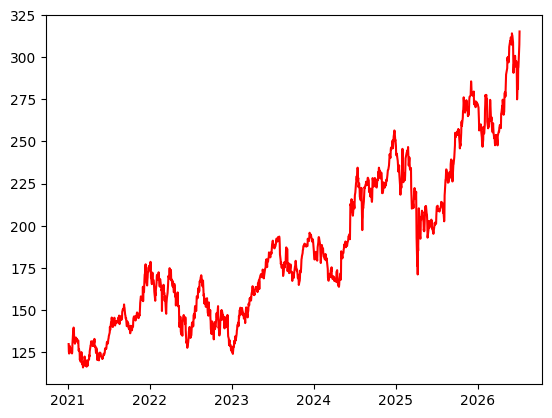

In [5]:
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['open_aapl'],color='red')

In [6]:
df['log_return'] = np.log((df['close_aapl'])/df['close_aapl'].shift(1))
df.head()

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return
0,2021-01-04,125.740868,129.821783,123.166001,129.734338,143301900,NaN
1,2021-01-05,127.295456,128.004769,124.788605,125.235569,97664900,0.012288
2,2021-01-06,123.010529,127.334363,122.796765,124.098776,155088000,-0.034241
3,2021-01-07,127.208015,127.897891,124.234778,124.720602,109578200,0.033554
4,2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200,0.008594


In [7]:
value = df.iloc[0,1]
value

np.float64(125.7408676147461)

In [8]:

# import math

# for i in range(df.shape[0]):
#     if i < 50 :
#         df.at[i, 'ma_distance'] = math.nan
#     else:
#         sum = 0
        
#         for j in range(50):
#             value = df.iloc[i-j,1]
#             sum = sum + value
#         sma_50 = sum/50
#         df.at[i, 'ma_distance']  = (df.iloc[i,1]/sma_50) - 1

df["MA_Distance"] = (
    df["close_aapl"] / 
    df["close_aapl"].rolling(window=50).mean()
) - 1


In [9]:
df.sample(5)

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return,MA_Distance
237,2021-12-10,175.436966,175.612948,170.783419,171.291794,115402700,0.027628,0.173361
838,2024-05-03,181.558899,185.142945,180.846048,184.796414,163224100,0.058096,0.063761
218,2021-11-12,146.635818,147.036638,144.181939,145.110692,63804000,0.014235,0.019588
834,2024-04-29,171.776947,174.281820,171.380926,171.648233,68169400,0.024505,0.002433
21,2021-02-03,130.142410,131.920526,129.821765,131.910800,89880900,-0.007809,NaN


In [10]:
# RSI (relative strength index)
# pure math
change = df['close_aapl'] - df['close_aapl'].shift(1)
gaint = np.maximum(change,0)
losst = np.maximum(-change,0)
df['RSI'] = np.nan
gain_sum_15 = 0
for i in range(1,15):
    gain_sum_15 = gain_sum_15 + gaint.iloc[i]
avg_gain_15 = gain_sum_15/14

loss_sum_15 = 0
for i in range(1,15):
    loss_sum_15 = loss_sum_15 + losst.iloc[i]
avg_loss_15 = loss_sum_15/14

RS15 = avg_gain_15/avg_loss_15
RSI15 = 100 - (100/(1+RS15))
df.at[14,'RSI'] = RSI15
avg_gain = avg_gain_15
avg_loss = avg_loss_15
for i in range(15,len(df)):

    avg_gain = ((avg_gain*13) + gaint.iloc[i])/14
    avg_loss = ((avg_loss*13) + losst.iloc[i])/14
    if avg_loss == 0 :
        df.at[i,'RSI'] = 100
    else:
        RS = avg_gain/avg_loss
        df.at[i: ,'RSI'] = 100 - (100/(1+RS))

df['RSI']

        



,RSI
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1377,46.925545
1378,50.986104
1379,60.276634
1380,62.444675


In [11]:
# 2. production ready 
delta = df['close_aapl'].diff()
gain = delta.clip(lower=0)
loss = delta.clip(upper=0).abs()

avg_gain = gain.ewm(com=13,adjust=False).mean()
avg_loss = loss.ewm(com=13,adjust=False).mean()

rs = avg_gain/avg_loss
df['RSI_production'] = 100 - (100/(1+rs))

df.sample(5)

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return,MA_Distance,RSI,RSI_production
757,2024-01-08,183.483093,183.522654,179.468538,180.051930,59144500,0.023887,-0.011065,41.372699,41.372699
1148,2025-07-31,206.749786,209.010805,206.341403,207.666149,80698400,-0.007105,0.010729,45.118234,45.118234
253,2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400,-0.012773,0.100233,61.914699,61.914699
1275,2026-02-02,269.509308,269.988398,258.729317,259.547804,73913400,0.039779,0.006199,62.457065,62.457065
299,2022-03-11,151.462540,155.916460,151.237401,155.573845,96970100,-0.024199,-0.081877,36.267289,36.267289


In [12]:
# avg true Range (ATR)
TR = pd.concat([
    df['high_aapl'] - df['low_aapl'],
    np.abs(df['high_aapl'] - df['close_aapl'].shift(1)),
    np.abs(df['low_aapl'] - df['close_aapl'].shift(1))
],axis=1).max(axis=1)

df['ATR'] = TR.ewm(alpha=1/14,adjust=False).mean()
df.sample(5)

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return,MA_Distance,RSI,RSI_production,ATR
1073,2025-04-11,197.108521,198.491214,185.082069,185.121867,87435900,0.039792,-0.117210,43.094125,43.094125,11.297850
601,2023-05-24,169.464264,170.036247,168.162521,168.724633,45143500,0.001631,0.037332,55.867238,55.867238,2.524622
1099,2025-05-20,206.042587,207.646226,204.219817,206.849384,42496600,-0.009239,-0.001749,50.044535,50.044535,6.440146
867,2024-06-14,210.665115,213.322092,209.485333,212.013436,70122700,-0.008202,0.159614,75.881676,75.881676,4.522564
202,2021-10-21,145.924240,146.080438,144.352537,145.270180,61421000,0.001473,0.015113,61.532390,61.532408,2.578987


In [16]:
# On Balance Volume (OBV)
direction = np.sign(df['close_aapl'].diff())
dir_volume = df['volume_aapl'] * direction
df['OBV'] = dir_volume.fillna(0).cumsum()
df.sample(5)

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return,MA_Distance,RSI,RSI_production,ATR,OBV
440,2022-10-03,139.840683,140.449336,135.167879,135.678358,114311700,0.030289,-0.106681,36.058197,36.058197,4.831412,-6.246165e+08
1097,2025-05-16,210.425201,211.730038,208.941099,211.520861,54737900,-0.000899,0.014558,54.979680,54.979680,6.623287,1.356715e+09
930,2024-09-16,214.710480,215.603777,212.328328,214.928829,59357400,-0.028168,-0.028908,39.142145,39.142145,4.917398,1.320702e+09
1269,2026-01-23,247.580017,248.947487,244.226247,246.861366,41689000,-0.001249,-0.080545,22.292079,22.292079,4.862397,2.144150e+09
1338,2026-05-04,276.575165,280.371685,274.606977,279.402577,46668400,-0.011886,0.058771,61.767600,61.767600,6.535526,2.458039e+09


In [17]:
# Rolling Z-Score
mean = df['close_aapl'].rolling(20).mean()
std = df['close_aapl'].rolling(20).std()
df['Z_score'] = (df['close_aapl'] - mean)/std
df.sample(5)

,Date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl,log_return,MA_Distance,RSI,RSI_production,ATR,OBV,Z_score
961,2024-10-29,231.931381,232.586474,230.591435,231.365630,35417200,0.001156,0.028911,57.170745,57.170745,4.029780,1.359614e+09,0.833601
326,2022-04-20,163.698517,165.313682,162.592390,165.196206,67929800,-0.001016,-0.001276,47.438325,47.438325,3.988390,-3.011454e+08,-1.038166
604,2023-05-30,174.848770,176.515408,174.128867,174.513474,55964400,0.010603,0.062274,67.220738,67.220738,2.588194,3.042843e+08,1.741065
722,2023-11-15,185.905655,187.378983,185.678233,185.747457,53790500,0.003036,0.066874,69.185080,69.185080,3.095867,6.646608e+08,1.655892
474,2022-11-18,148.765121,150.151594,147.467159,149.768103,74829600,0.003775,0.029935,56.065700,56.065700,5.065309,-3.652776e+08,0.789915
